# MHR kinematics, from the ground up

This notebook explains **how MHR turns a list of numbers into a posed human body**, starting
from the very beginning. No prior graphics or 3D maths is assumed.

We build the ideas in the order they depend on each other:

| Part | Question it answers |
|---|---|
| 1 | What geometry is MHR actually representing? |
| 2 | What is a joint, and how is a skeleton stored? |
| 3 | What is a coordinate frame? |
| 4 | What is a transformation, and how do rotations and translations get written down? |
| 5 | How does MHR write down one joint's transformation? |
| 6 | What is forward kinematics? (we write it ourselves, in 12 lines) |
| 7 | Where do the 204 named parameters fit in? |
| 8 | What happens to the body when I change one parameter? |
| 9 | How do the individual transformations combine into the final pose? |

Everything is computed live, and every claim is checked against the library rather than
asserted. Read it top to bottom the first time — later parts use names defined earlier.

---
## Part 0 — Setup

Three things get loaded here:

* **`model`** — the MHR body model. It is a `torch.nn.Module`: numbers in, a 3D body out.
* **`character`** — the *rig* inside the model: the skeleton and the wiring between parameters
  and joints. This is where all the kinematics lives, and it is what most of this notebook pokes at.
* **helpers** from `mhr_kit`, this workspace's thin convenience layer over the official package.

We load **level of detail 4**: the same skeleton as every other LOD (kinematics do not depend on
LOD at all), but a light 2 461-vertex mesh, so every cell runs in well under a second.

In [1]:
import pathlib
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# Run correctly whether the notebook sits in the repo root or in "demos ipynb/".
ROOT = pathlib.Path.cwd()
if not (ROOT / "mhr_kit").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from mhr_kit import render
from mhr_kit.model import load_mhr, faces, joint_names, parameter_names

torch.set_grad_enabled(False)          # we only ever run the model forwards here
np.set_printoptions(precision=3, suppress=True)

model = load_mhr(lod=4)                # the body model
character = model.character            # the rig: skeleton + parameter wiring
skeleton = character.skeleton          # the 127 joints

JOINT_NAMES = joint_names(model)               # 127 names, in skeleton order
PARAMETER_NAMES = parameter_names(model)       # 204 names, in parameter order

print("mesh vertices    ", np.asarray(character.mesh.vertices).shape[0])
print("mesh triangles   ", faces(model).shape[0])
print("skeleton joints  ", len(JOINT_NAMES))
print("model parameters ", len(PARAMETER_NAMES))

mesh vertices     2461
mesh triangles    4918
skeleton joints   127
model parameters  204


Two lookup dictionaries make the rest of the notebook readable. Never hard-code an index —
look the name up.

In [2]:
# name -> position in the array. "l_" and "r_" are the body's own left and right.
JOINT_INDEX = {name: i for i, name in enumerate(JOINT_NAMES)}
PARAMETER_INDEX = {name: i for i, name in enumerate(PARAMETER_NAMES)}

print("joint 'l_lowarm' is at index", JOINT_INDEX["l_lowarm"])
print("parameter 'l_elbow_bend' is at index", PARAMETER_INDEX["l_elbow_bend"])

joint 'l_lowarm' is at index 76
parameter 'l_elbow_bend' is at index 46


### The one function everything else calls

`model(...)` wants three vectors. Only the middle one — the 204 **model parameters** — is about
pose, and that is the only one this notebook varies. The other two describe *who the person is*
(body shape) and *what their face is doing*; we leave both at zero, which gives the average body
with a neutral face.

Rather than remembering that `l_elbow_bend` lives at index 33, we set parameters **by name**.

In [3]:
def make_parameters(**named_values):
    """Build the (1, 204) model-parameter vector, setting parameters by name.

    Any parameter not mentioned stays at 0, which is its rest value. So
    `make_parameters()` with no arguments is the rest pose.

    Args:
        **named_values: e.g. `l_elbow_bend=1.2`. Rotations are in radians.

    Returns:
        A (1, 204) float32 tensor ready to hand to `model(...)`.
    """
    parameters = torch.zeros(1, 204)
    for name, value in named_values.items():
        parameters[0, PARAMETER_INDEX[name]] = value      # look the name up, write the number
    return parameters


# The two inputs we never change: average body shape, neutral face.
AVERAGE_BODY = torch.zeros(1, 45)
NEUTRAL_FACE = None


def pose_body(**named_values):
    """Pose the body and return both of the things MHR gives you.

    Args:
        **named_values: parameters by name, as in `make_parameters`.

    Returns:
        vertices: (V, 3) numpy array — the skin, in centimetres.
        joint_positions: (127, 3) numpy array — where each joint ended up, in centimetres.
    """
    parameters = make_parameters(**named_values)
    vertices, skeleton_state = model(AVERAGE_BODY, parameters, NEUTRAL_FACE)

    # skeleton_state is (1, 127, 8) = (x, y, z, qx, qy, qz, qw, scale) per joint, in world
    # space. The first three columns are exactly the joint positions, so this is just a slice.
    joint_positions = skeleton_state[0, :, :3].numpy()
    return vertices[0].numpy(), joint_positions


rest_vertices, rest_joints = pose_body()          # no arguments = the rest pose
print("vertices     ", rest_vertices.shape)
print("joints       ", rest_joints.shape)
print("body height  ", rest_vertices[:, 1].max() - rest_vertices[:, 1].min(), "cm")

vertices      (2461, 3)
joints        (127, 3)
body height   172.5604 cm


---
## Part 1 — What is the geometry being represented?

MHR represents a human as **two separate objects that move together**:

1. **A surface (the skin).** A big list of 3D points, called *vertices*, plus a list of triangles
   saying which points to connect. That is all a 3D mesh ever is.
2. **A skeleton.** 127 *joints* arranged in a tree, like the bones in a real body. The skeleton is
   invisible — it exists only to move the skin.

The skeleton is the driver. You pose the skeleton, and every vertex of the skin follows the
joints near it. So **kinematics is entirely a story about the skeleton**; the skin is along for
the ride.

> This is worth pausing on if you know SMPL: there, joint locations are *computed from* the
> surface. In MHR the skeleton is an independent object with its own bone lengths and its own
> rotation conventions, and the surface is attached to it.

Let's look at both.

In [4]:
mesh_triangles = faces(model)                 # (F, 3) — each row is 3 indices into the vertices

print("First 3 vertices (x, y, z in cm):")
print(rest_vertices[:3])
print()
print("First 3 triangles (which vertices to join):")
print(mesh_triangles[:3])
print()
print("So triangle 0 connects these three points:")
print(rest_vertices[mesh_triangles[0]])

First 3 vertices (x, y, z in cm):
[[  7.159 158.438   3.975]
 [  8.798 161.462   1.124]
 [  8.349 162.258   2.721]]

First 3 triangles (which vertices to join):
[[342 354 356]
 [356 321 342]
 [342 321 320]]

So triangle 0 connects these three points:
[[ -1.931 155.522  12.865]
 [ -2.026 155.563  12.853]
 [ -1.619 155.695  13.13 ]]


### The world coordinate system

Before drawing anything, we need to know what x, y and z mean. Measured from the rest pose:

* **units are centimetres**,
* **+y is up** (the head has the largest y),
* **+z is the direction the body faces** (its nose points along +z),
* **+x** completes the set — it points toward the body's *left* (its left wrist has positive x).

The point `(0, 0, 0)` is on the floor between the feet. This is the **world frame**, and it never
moves. Everything in the notebook is eventually expressed in it.

In [5]:
# Check each of those claims rather than trusting the prose.
lowest_point = rest_vertices[:, 1].min()
head_top = rest_vertices[rest_vertices[:, 1].argmax()]

# For "which way is forward?" look only at the head: in a T-pose the hands stick out
# further forward than the nose does, so the whole-body maximum would find a fingertip.
head_vertices = rest_vertices[rest_vertices[:, 1] > 160.0]
nose = head_vertices[head_vertices[:, 2].argmax()]

print(f"lowest vertex is at y = {lowest_point:6.2f} cm   -> the floor is y = 0")
print(f"highest vertex is at   {head_top}   -> +y is up, and this body is {head_top[1]:.0f} cm tall")
print(f"the nose is at         {nose}   -> +z is the way the body faces")

left_wrist = rest_joints[JOINT_INDEX["l_wrist"]]
right_wrist = rest_joints[JOINT_INDEX["r_wrist"]]
print(f"\nleft wrist  {left_wrist}")
print(f"right wrist {right_wrist}")
print("   -> the LEFT wrist has positive x, so +x is the body's left and -x is its right.")
print("      (Left and right always mean the body's own, as seen from inside it.)")

lowest vertex is at y =  -0.04 cm   -> the floor is y = 0
highest vertex is at   [ -0.    172.521   5.314]   -> +y is up, and this body is 173 cm tall
the nose is at         [  0.    160.815  14.586]   -> +z is the way the body faces

left wrist  [ 53.986 111.331  13.185]
right wrist [-53.986 111.331  13.185]
   -> the LEFT wrist has positive x, so +x is the body's left and -x is its right.
      (Left and right always mean the body's own, as seen from inside it.)


### Drawing tools

Three small drawing helpers, used by every picture below. Read them once; after this they are
just `draw_skeleton(...)` and `photograph(...)`.

There is one trap worth knowing about, handled by `for_plotting`: matplotlib's 3D axes draw their
*third* coordinate upwards, while MHR's up axis is its *second*. Reordering the columns naively
produces a picture that looks perfectly like a person but has left and right swapped.

In [6]:
# The parent of every joint (which joint it hangs off). -1 marks the root, which has no parent.
JOINT_PARENTS = np.asarray(skeleton.joint_parents)


def for_plotting(points):
    """Re-order MHR's (x, y, z) into the order matplotlib's 3D axes want.

    Matplotlib draws its THIRD coordinate upwards, but MHR's up axis is y. So the
    columns have to be swapped -- and the swap has to be done carefully:

        (x, z, y)  would put y up, but it MIRRORS the body: swapping two axes of a
                   right-handed frame makes it left-handed, so left and right trade
                   places and every picture quietly lies to you.
        (x, -z, y) puts y up AND stays right-handed. This is the correct one.

    Args:
        points: (..., 3) array in MHR world coordinates.

    Returns:
        (..., 3) array ready to hand to a matplotlib 3D axes.
    """
    points = np.asarray(points)
    return np.stack([points[..., 0], -points[..., 2], points[..., 1]], axis=-1)


def draw_skeleton(axes, joint_positions, highlight=(), title="", color="#3b6ea5", elevation=12, azimuth=-72):
    """Draw a stick figure: one line segment per parent->child bone.

    Args:
        axes: a matplotlib 3D axes to draw into.
        joint_positions: (127, 3) world positions in cm, in MHR coordinates.
        highlight: joint names to draw thick and orange (a chain you want to follow).
        title: title text for the panel.
        color: colour of the ordinary bones.
        elevation, azimuth: viewing direction, in degrees.
    """
    highlighted = {JOINT_INDEX[name] for name in highlight}
    plotted = for_plotting(joint_positions)          # swap to plotting order exactly once

    for joint, parent in enumerate(JOINT_PARENTS):
        if parent < 0:
            continue                                 # the root has no bone above it
        start, end = plotted[parent], plotted[joint]
        is_highlighted = joint in highlighted and parent in highlighted
        axes.plot(*zip(start, end),
                  color="#e07b39" if is_highlighted else color,
                  linewidth=3.4 if is_highlighted else 1.0,
                  alpha=1.0 if is_highlighted else 0.5,
                  zorder=3 if is_highlighted else 2)

    if highlighted:
        axes.scatter(*plotted[sorted(highlighted)].T, s=26, color="#e07b39", zorder=4)

    axes.set_box_aspect((1, 1, 1))
    axes.view_init(elev=elevation, azim=azimuth)
    axes.set_xlabel("x (body's left)", fontsize=8)
    axes.set_ylabel("-z (behind)", fontsize=8)
    axes.set_zlabel("y (up)", fontsize=8)
    axes.tick_params(labelsize=6, pad=0)
    # 3D panels are small here; four ticks per axis keeps the labels from colliding.
    for axis in (axes.xaxis, axes.yaxis, axes.zaxis):
        axis.set_major_locator(plt.MaxNLocator(4))
    axes.set_title(title, fontsize=9)


def equalise(axes, points, pad=6.0):
    """Give a 3D axes equal scaling on all three axes, so the body is not stretched."""
    plotted = for_plotting(points).reshape(-1, 3)
    centre = 0.5 * (plotted.min(0) + plotted.max(0))
    reach = 0.5 * float((plotted.max(0) - plotted.min(0)).max()) + pad
    axes.set_xlim(centre[0] - reach, centre[0] + reach)
    axes.set_ylim(centre[1] - reach, centre[1] + reach)
    axes.set_zlim(centre[2] - reach, centre[2] + reach)


def photograph(vertices, azimuth=25, elevation=6, size=(420, 540)):
    """Render the skin to an RGB image with the workspace's CPU renderer.

    Args:
        vertices: (V, 3) posed vertices in cm.
        azimuth: degrees around the body; 0 looks at its front.
        elevation: degrees above the horizon.
        size: output (width, height) in pixels.

    Returns:
        An (H, W, 3) uint8 image.
    """
    camera = render.orbit_camera(vertices, azimuth=azimuth, elevation=elevation, size=size)
    return render.render(vertices, mesh_triangles, camera)

Here is the rest pose: skin on the left, skeleton on the right. **The rest pose is what you get
when every parameter is zero** — a T-pose, standing on the floor, facing +z.

Notice how many joints there are in the hands. Of the 127 joints, 50 are fingers.

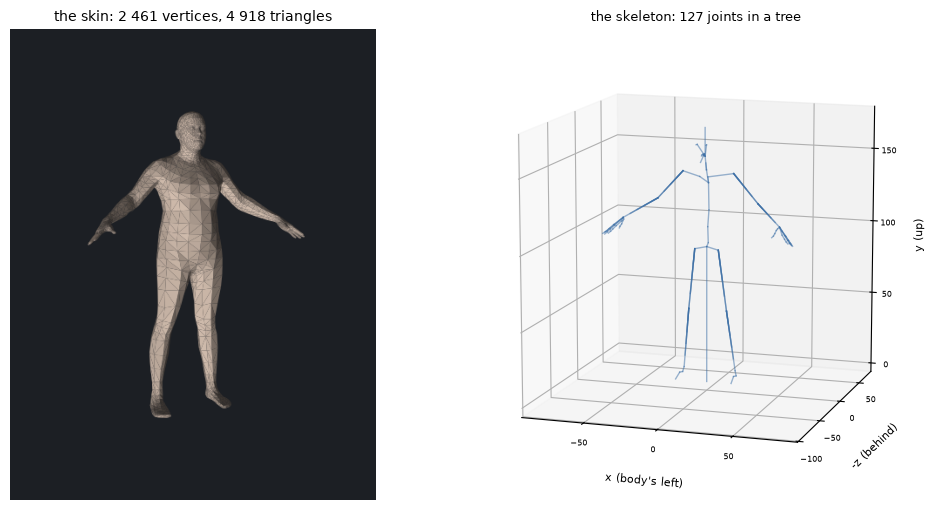

In [7]:
figure = plt.figure(figsize=(10.5, 5.2))

axes_image = figure.add_subplot(1, 2, 1)
axes_image.imshow(photograph(rest_vertices))
axes_image.axis("off")
axes_image.set_title("the skin: 2 461 vertices, 4 918 triangles", fontsize=10)

axes_3d = figure.add_subplot(1, 2, 2, projection="3d")
draw_skeleton(axes_3d, rest_joints, title="the skeleton: 127 joints in a tree")
equalise(axes_3d, rest_joints)

plt.tight_layout()
plt.show()

---
## Part 2 — What is a joint?

A joint in MHR is **not** a blob of anatomy. It is three pieces of data:

| piece | array | meaning |
|---|---|---|
| a **name** | `skeleton.joint_names` | `"l_lowarm"`, `"c_head"`, … |
| a **parent** | `skeleton.joint_parents` | which joint it hangs off; `-1` for the root |
| an **offset** | `skeleton.offsets` | how far it sits from its parent, in cm — *this is the bone length* |

plus one fixed rotation we will meet in Part 5.

That's it. A "bone" is not a separate object at all: **the bone is the gap between a joint and its
parent**, and its length is the size of the offset.

In [8]:
JOINT_OFFSETS = np.asarray(skeleton.offsets)         # (127, 3) cm, measured in the PARENT's frame

def describe_joint(name):
    """Print the raw data MHR stores for one joint."""
    joint = JOINT_INDEX[name]
    parent = JOINT_PARENTS[joint]
    offset = JOINT_OFFSETS[joint]
    print(f"joint      {name}  (index {joint})")
    print(f"parent     {JOINT_NAMES[parent] if parent >= 0 else 'none - this is the root'}")
    print(f"offset     {offset}  cm, in the parent's frame")
    print(f"length     {np.linalg.norm(offset):.2f} cm   <- the length of this bone")
    print()

describe_joint("l_uparm")     # the upper arm hangs off the collarbone
describe_joint("l_lowarm")    # the forearm hangs off the upper arm: this offset IS the upper-arm length
describe_joint("body_world")  # the root

joint      l_uparm  (index 75)
parent     l_clavicle
offset     [17.651 -0.    -0.   ]  cm, in the parent's frame
length     17.65 cm   <- the length of this bone

joint      l_lowarm  (index 76)
parent     l_uparm
offset     [25.68  -0.046  0.   ]  cm, in the parent's frame
length     25.68 cm   <- the length of this bone

joint      body_world  (index 0)
parent     none - this is the root
offset     [0. 0. 0.]  cm, in the parent's frame
length     0.00 cm   <- the length of this bone



### The tree

Joints form a tree: every joint has exactly one parent, and they are stored in an order where
**a parent always comes before its children**. That ordering is what makes posing cheap — you can
sweep through the array once, front to back, and every parent is already finished when you reach
its children.

Walking *up* from any joint to the root gives you a **kinematic chain**. This is the single most
important idea in the notebook: moving a joint moves everything below it in the chain, and
nothing else.

In [9]:
def chain_to_root(name):
    """List the joints from `name` up to the root, as names.

    Walking up the parent links is the whole trick: this chain is exactly the set of
    joints whose rotations affect where `name` ends up.
    """
    chain = []
    joint = JOINT_INDEX[name]
    while joint >= 0:                       # -1 means "no parent", i.e. we reached the root
        chain.append(JOINT_NAMES[joint])
        joint = JOINT_PARENTS[joint]
    return chain


print("From the left wrist up to the root:\n")
for step, name in enumerate(chain_to_root("l_wrist")):
    print("   " * step + "-> " + name)

From the left wrist up to the root:

-> l_wrist
   -> l_wrist_twist
      -> l_lowarm
         -> l_uparm
            -> l_clavicle
               -> c_spine3
                  -> c_spine2
                     -> c_spine1
                        -> c_spine0
                           -> root
                              -> body_world


Read that list bottom-up and it is the anatomy: `body_world` → `root` (the pelvis) → four spine
joints → `l_clavicle` (the collarbone) → `l_uparm` → `l_lowarm` (the elbow) → `l_wrist_twist` →
`l_wrist`.

Two things to notice, because they surprise people:

* **The names are rig names, not textbook anatomy.** MHR's "shoulder" joint is called
  `l_clavicle`, the elbow is `l_lowarm`, the knee is `l_lowleg`, the ankle is `l_foot`. Each joint
  is named after *the bone that hangs below it*.
* **`l_wrist_twist` is an extra joint that has no anatomical counterpart.** Your forearm twists
  along its whole length rather than at one point, so MHR inserts helper joints that each take a
  fraction of the twist. This makes the skin twist gradually instead of pinching at the wrist.

Here is the tree itself, with fingers folded away so it fits on a screen.

In [10]:
def children_of(joint):
    """Indices of the joints whose parent is `joint` (direct children only)."""
    # `recursive` is a required argument, and it rejects numpy integers -- hence int(...).
    return list(skeleton.get_child_joints(int(joint), False))


def print_tree(joint=0, indent="", skip=("thumb", "index", "middle", "ring", "pinky")):
    """Print the joint tree, hiding the finger sub-trees so the body is readable."""
    name = JOINT_NAMES[joint]
    if any(word in name for word in skip):
        return
    kids = [k for k in children_of(joint) if not any(w in JOINT_NAMES[k] for w in skip)]
    hidden = len(children_of(joint)) - len(kids)
    print(f"{indent}{name}" + (f"   (+{hidden} finger joints)" if hidden else ""))
    for position, kid in enumerate(kids):
        last = position == len(kids) - 1
        print_tree(kid, indent + "   ", skip)


print_tree()

body_world
   root
      l_upleg
         l_lowleg
            l_foot
               l_talocrural
                  l_subtalar
                     l_transversetarsal
                        l_ball
            l_lowleg_twist1_proc
            l_lowleg_twist2_proc
            l_lowleg_twist3_proc
            l_lowleg_twist4_proc
         l_upleg_twist0_proc
         l_upleg_twist1_proc
         l_upleg_twist2_proc
         l_upleg_twist3_proc
         l_upleg_twist4_proc
      r_upleg
         r_lowleg
            r_foot
               r_talocrural
                  r_subtalar
                     r_transversetarsal
                        r_ball
            r_lowleg_twist1_proc
            r_lowleg_twist2_proc
            r_lowleg_twist3_proc
            r_lowleg_twist4_proc
         r_upleg_twist0_proc
         r_upleg_twist1_proc
         r_upleg_twist2_proc
         r_upleg_twist3_proc
         r_upleg_twist4_proc
      c_spine0
         c_spine1
            c_spine2
               

---
## Part 3 — What is a coordinate frame?

A **coordinate frame** is a starting point plus three directions. `(3, 0, 12)` is meaningless on
its own; it only means something once you say *"3 cm along which x, from where?"*

MHR uses two kinds of frame, and almost every confusion about kinematics is a confusion between
them:

* **The world frame.** One fixed frame for the whole scene: origin on the floor, +y up, +z
  forward. Final answers live here.
* **A local frame per joint.** *Every one of the 127 joints carries its own frame around with it.*
  Its origin is the joint itself, and its axes rotate when the joint rotates.

Bone offsets are stored in the **parent's local frame**. That is exactly why the rig works: the
forearm is stored as "24 cm along the upper arm's own x axis", which stays true no matter how the
shoulder is rotated. The shoulder rotates, the forearm's frame comes along, and the elbow lands
in the right place for free.

The picture below draws the local frame of a few joints in the rest pose. Red = the joint's own
x, green = y, blue = z.

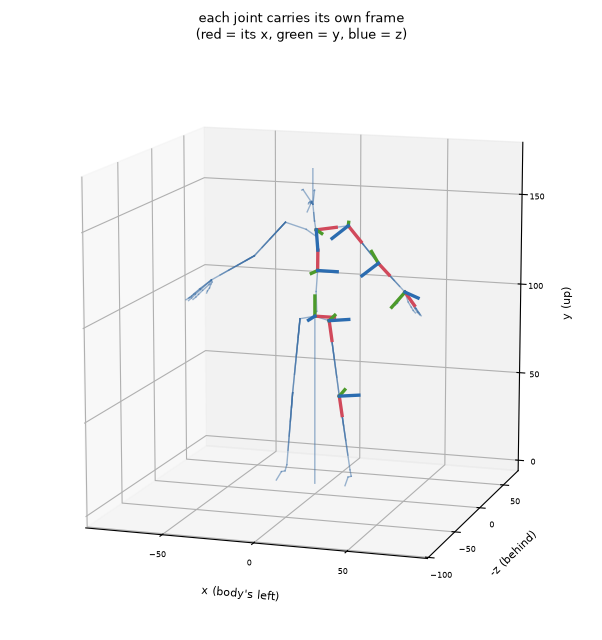

In [11]:
def joint_frames(**named_values):
    """Return each joint's world position AND its world rotation matrix.

    `model(...)` hands back rotations as quaternions (4 numbers). A rotation matrix
    (3x3) is easier to picture: its three columns ARE the joint's own x, y and z axes,
    written in world coordinates.

    Returns:
        positions: (127, 3) in cm.
        rotations: (127, 3, 3) rotation matrices, world space.
    """
    _, skeleton_state = model(AVERAGE_BODY, make_parameters(**named_values), NEUTRAL_FACE)
    state = skeleton_state[0].numpy()
    positions = state[:, :3]
    rotations = Rotation.from_quat(state[:, 3:7]).as_matrix()     # scipy wants (x, y, z, w) too
    return positions, rotations


def draw_axes(axes, origin, rotation, length=11.0):
    """Draw one joint's coordinate frame as three coloured arrows from `origin`.

    Column k of a rotation matrix IS that frame's k-th axis, written in world
    coordinates -- which is the whole reason we converted the quaternion to a matrix.
    """
    for column, colour in zip(range(3), ["#d1495b", "#4c9a2a", "#2b6cb0"]):
        tip = origin + rotation[:, column] * length
        # Convert the two endpoints to plotting order, exactly as draw_skeleton does.
        axes.plot(*zip(for_plotting(origin), for_plotting(tip)),
                  color=colour, linewidth=2.4, zorder=5)


positions, rotations = joint_frames()          # rest pose
shown = ["root", "c_spine2", "l_clavicle", "l_uparm", "l_lowarm", "l_wrist", "l_upleg", "l_lowleg"]

figure = plt.figure(figsize=(6.5, 6.5))
axes_3d = figure.add_subplot(projection="3d")
draw_skeleton(axes_3d, positions, title="each joint carries its own frame\n(red = its x, green = y, blue = z)")
for name in shown:
    draw_axes(axes_3d, positions[JOINT_INDEX[name]], rotations[JOINT_INDEX[name]])
equalise(axes_3d, positions)
plt.tight_layout()
plt.show()

Look at the red arrows on the arm and leg joints: **each joint's local x axis points straight down
its own bone.** That is a deliberate design choice, and Part 5 shows what MHR gets out of it.

---
## Part 4 — What is a transformation?

A transformation is a rule for moving points from one frame into another. We only ever need two
ingredients:

* a **translation** — a shift, "move 24 cm along x", written as a 3-vector $t$;
* a **rotation** — a turn about the origin, written as a $3\times3$ matrix $R$.

Applied to a point $p$, together they read $p' = R\,p + t$: *turn first, then shift.*

### Why a 4×4 matrix

Writing "$Rp + t$" is fine for one joint. But a body is a chain of ten of them, and you would end
up with a long nest of multiplications and additions. The trick every graphics library uses is to
glue $R$ and $t$ into a single $4\times4$ matrix, by tacking a 1 on the end of every point:

$$
\begin{bmatrix} p' \\ 1 \end{bmatrix}
=
\underbrace{\begin{bmatrix} R & t \\ 0\;0\;0 & 1 \end{bmatrix}}_{M}
\begin{bmatrix} p \\ 1 \end{bmatrix}
$$

Now *both* operations are one matrix, and — the point of the whole exercise — **chaining
transformations is just matrix multiplication**. This is what makes the forward-kinematics loop in
Part 6 four lines long.

In [12]:
def make_transform(rotation, translation):
    """Pack a 3x3 rotation and a 3-vector translation into one 4x4 matrix.

    The layout is fixed: rotation in the top-left 3x3 block, translation in the last
    column, and a bottom row of (0, 0, 0, 1) that just carries the appended 1 through.
    """
    matrix = np.eye(4)
    matrix[:3, :3] = rotation
    matrix[:3, 3] = translation
    return matrix


def apply_transform(matrix, point):
    """Apply a 4x4 transform to a single 3D point, and return a 3D point."""
    homogeneous = np.append(point, 1.0)          # (x, y, z) -> (x, y, z, 1)
    result = matrix @ homogeneous
    return result[:3]                            # drop the 1 again


# A worked example: turn 90 degrees about the z axis, then move 10 cm along x.
turn_90 = Rotation.from_euler("z", 90, degrees=True).as_matrix()
example = make_transform(turn_90, [10.0, 0.0, 0.0])

print("the 4x4 transform:")
print(example)
print()
print("the point (5, 0, 0) becomes:", apply_transform(example, [5.0, 0.0, 0.0]))
print("  -> the rotation swung it from +x round to +y, then the translation pushed it back along x")

the 4x4 transform:
[[ 0. -1.  0. 10.]
 [ 1.  0.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

the point (5, 0, 0) becomes: [10.  5.  0.]
  -> the rotation swung it from +x round to +y, then the translation pushed it back along x


### Two bones, by hand

Before touching MHR's 127 joints, here is the entire idea on a 2-bone arm we build ourselves.
The upper arm is 30 cm, the forearm is 25 cm, both stored *along their own x axis*, exactly the
way MHR stores offsets.

Read this cell carefully — Part 6 is this cell with a loop around it.

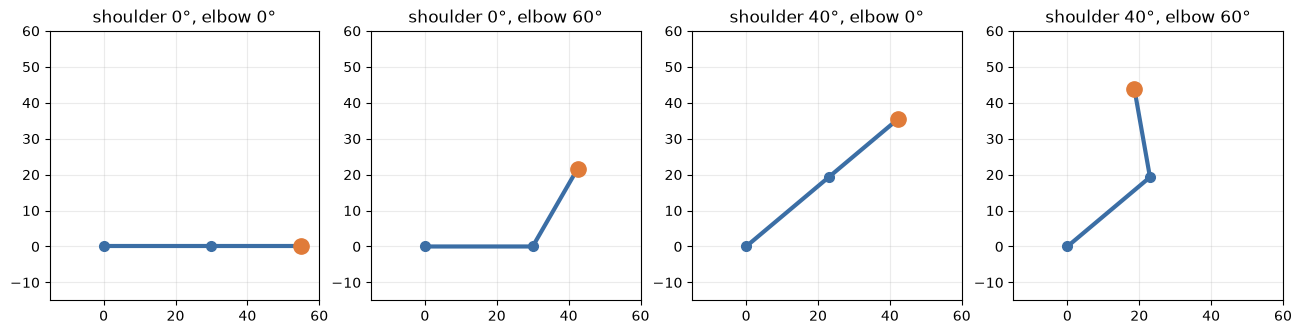

hand position with shoulder 40°, elbow 60°: [18.64 43.9   0.  ]


In [13]:
def toy_arm(shoulder_degrees, elbow_degrees):
    """A hand-built two-bone arm, to show how transforms compose.

    The shoulder sits at the world origin. Each bone is stored as an offset along its
    parent's own x axis, so rotating the parent carries the child along automatically.

    Returns:
        The world positions of the shoulder, the elbow, and the hand.
    """
    # --- the shoulder: at the origin, rotated by the shoulder angle -----------------
    shoulder_rotation = Rotation.from_euler("z", shoulder_degrees, degrees=True).as_matrix()
    shoulder_to_world = make_transform(shoulder_rotation, [0.0, 0.0, 0.0])

    # --- the elbow, described IN THE SHOULDER'S FRAME ------------------------------
    # 30 cm along the upper arm's x axis, then the elbow's own bend on top.
    elbow_rotation = Rotation.from_euler("z", elbow_degrees, degrees=True).as_matrix()
    elbow_to_shoulder = make_transform(elbow_rotation, [30.0, 0.0, 0.0])

    # Compose: going elbow -> shoulder -> world is one multiplication.
    elbow_to_world = shoulder_to_world @ elbow_to_shoulder

    # --- the hand, described IN THE ELBOW'S FRAME ----------------------------------
    hand_to_elbow = make_transform(np.eye(3), [25.0, 0.0, 0.0])   # 25 cm, no extra rotation
    hand_to_world = elbow_to_world @ hand_to_elbow

    # The last column of a transform is where its own origin sits in world coordinates.
    return (shoulder_to_world[:3, 3], elbow_to_world[:3, 3], hand_to_world[:3, 3])


figure, panels = plt.subplots(1, 4, figsize=(13, 3.4))
for panel, (shoulder, elbow) in zip(panels, [(0, 0), (0, 60), (40, 0), (40, 60)]):
    points = np.array(toy_arm(shoulder, elbow))
    panel.plot(points[:, 0], points[:, 1], "-o", color="#3b6ea5", linewidth=3, markersize=7)
    panel.plot(points[2, 0], points[2, 1], "o", color="#e07b39", markersize=11)   # the hand
    panel.set(xlim=(-15, 60), ylim=(-15, 60), title=f"shoulder {shoulder}°, elbow {elbow}°")
    panel.set_aspect("equal"); panel.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("hand position with shoulder 40°, elbow 60°:", toy_arm(40, 60)[2].round(2))

Compare the second and third panels. Bending the **elbow** moved only the hand. Rotating the
**shoulder** by the same amount moved the elbow *and* the hand, and it did so without anyone
recomputing the forearm: the forearm's offset was written in the shoulder's frame, so it simply
came along.

**That is forward kinematics.** Everything left in this notebook is the same operation, with
MHR's real numbers instead of ours.

---
## Part 5 — How MHR writes down one joint's transformation

MHR's local transform — the one taking a joint's frame into its **parent's** frame — has four
pieces rather than our toy's two:

$$
L_j \;=\;
\underbrace{T(\text{offset}_j + t_j)}_{\text{1. the bone}}
\;\cdot\;
\underbrace{R^{\text{pre}}_j}_{\text{2. the fixed pre-rotation}}
\;\cdot\;
\underbrace{R_{xyz}(r_j)}_{\text{3. the pose}}
\;\cdot\;
\underbrace{S(2^{s_j})}_{\text{4. the scale}}
$$

Taking them one at a time:

1. **The bone.** The rest offset from Part 2, plus an animated translation $t_j$ which is zero for
   nearly every joint (only the root really translates).
2. **The pre-rotation** $R^{\text{pre}}_j$: a *fixed* rotation baked into the rig, never animated.
   It is what tilts each joint's frame so that **its x axis runs down the bone** — the red arrows
   in Part 3.
3. **The pose** $R_{xyz}(r_j)$: three angles in radians, applied as an x-then-y-then-z Euler
   rotation. **These three numbers per joint are the pose.** Everything else in the formula is
   constant.
4. **The scale**, $2^{s_j}$ — note base 2, not $e$. It stretches a bone; at rest $s_j = 0$, so
   the factor is 1.

### Why the pre-rotation earns its keep

Because $R^{\text{pre}}$ puts x down the bone, and because the pose rotation is applied *after*
it, the three pose angles get consistent, nameable meanings on every joint in the body:

* rotation about **x** = **twist along the bone** — which is why parameters are called
  `l_uparm_twist`, `spine_twist0`;
* rotations about **y** and **z** = swinging the bone about the joint.

Let's confirm that by rotating one joint about each axis in turn and watching where its child
goes.

In [14]:
def child_movement(joint_name, axis, angle=0.6):
    """How far does a joint's child move when the joint rotates about one axis?

    A twist about the bone should barely move the child (it is ON the axis); a swing
    should move it a lot. This measures which is which.

    Args:
        joint_name: the joint to rotate.
        axis: 0, 1 or 2 for the joint's local x, y or z.
        angle: rotation in radians.

    Returns:
        Distance the first child travelled, in cm.
    """
    joint = JOINT_INDEX[joint_name]
    child = children_of(joint)[0]

    # Write into the joint's raw rotation slot directly, bypassing the named parameters.
    # Each joint owns 7 numbers: (tx, ty, tz, rx, ry, rz, scale) -- so its rx sits at 7*j + 3.
    before = np.zeros(889, dtype=np.float32)
    after = before.copy()
    after[7 * joint + 3 + axis] = angle

    import pymomentum.geometry as geometry
    positions_before = np.asarray(geometry.joint_parameters_to_skeleton_state(character, before))[child, :3]
    positions_after = np.asarray(geometry.joint_parameters_to_skeleton_state(character, after))[child, :3]
    return float(np.linalg.norm(positions_after - positions_before))


print("Rotating a joint 0.6 rad about its own axes -- how far its child moves (cm):\n")
print(f"{'joint':<14}{'x (twist)':>12}{'y (swing)':>12}{'z (swing)':>12}")
for name in ["l_uparm", "l_lowarm", "l_upleg", "c_spine1"]:
    distances = [child_movement(name, axis) for axis in range(3)]
    print(f"{name:<14}" + "".join(f"{d:>12.2f}" for d in distances))

Rotating a joint 0.6 rad about its own axes -- how far its child moves (cm):

joint            x (twist)   y (swing)   z (swing)
l_uparm               0.03       15.18       15.18
l_lowarm              0.00       15.96       15.96
l_upleg               0.46       24.81       24.81
c_spine1              1.27        6.52        6.64


The x column is near zero everywhere while y and z are large: rotating about x spins the bone
about its own length, so the child — which sits *on* that axis — hardly moves at all. The
pre-rotation is what makes that true for every joint at once.

(The x column is not *exactly* zero because the child bone is not perfectly collinear with its
parent — a real skeleton is slightly knock-kneed and its joints are offset sideways.)

---
## Part 6 — Forward kinematics

**Forward kinematics** means: *given every joint's angles, where does every joint end up in the
world?* Angles in, positions out. (The reverse direction — positions in, angles out — is
*inverse* kinematics, and it is a much harder problem, solved by optimisation.)

The algorithm is the toy arm from Part 4, run over a tree:

> For each joint, in stored order: build its local transform $L_j$. If it is the root, its world
> transform is $L_j$. Otherwise multiply its parent's already-computed world transform by $L_j$.

The stored order guarantees the parent is always finished first, so a single pass suffices —
no recursion, no bookkeeping.

We now write that ourselves and check it against the library.

In [15]:
JOINT_PRE_ROTATIONS = np.asarray(skeleton.pre_rotations)     # (127, 4) fixed quaternions (x, y, z, w)


def local_transform(joint, translation, euler_angles, scale_exponent):
    """Build one joint's 4x4 transform into its parent's frame -- the formula from Part 5.

    Args:
        joint: joint index.
        translation: (3,) animated translation, in cm. Usually zeros.
        euler_angles: (3,) pose rotation (rx, ry, rz) in radians, applied x then y then z.
        scale_exponent: the joint's scale parameter s; the actual factor is 2**s.

    Returns:
        A 4x4 matrix.
    """
    # 1. the bone: rest offset plus any animated translation
    offset = JOINT_OFFSETS[joint] + translation

    # 2. the fixed pre-rotation, which aligns x with the bone
    pre_rotation = Rotation.from_quat(JOINT_PRE_ROTATIONS[joint]).as_matrix()

    # 3. the pose, three Euler angles applied in x, y, z order
    pose_rotation = Rotation.from_euler("xyz", euler_angles).as_matrix()

    # 4. the scale, base 2 -- and it multiplies into the rotation block
    scale = 2.0 ** scale_exponent

    return make_transform(pre_rotation @ pose_rotation * scale, offset)


def forward_kinematics(joint_parameters):
    """Walk the tree once and return every joint's world transform.

    Args:
        joint_parameters: (127, 7) array; each row is (tx, ty, tz, rx, ry, rz, scale).

    Returns:
        (127, 4, 4) world transforms, one per joint.
    """
    world = np.zeros((len(JOINT_PARENTS), 4, 4))

    for joint, parent in enumerate(JOINT_PARENTS):
        local = local_transform(joint,
                                joint_parameters[joint, 0:3],     # translation
                                joint_parameters[joint, 3:6],     # rotation
                                joint_parameters[joint, 6])       # scale
        # The one line that makes it kinematics: a child is its parent, then itself.
        world[joint] = local if parent < 0 else world[parent] @ local

    return world

To test it we need a `(127, 7)` array of joint parameters. Part 7 explains where those come from;
for now, borrow the library's converter and check our loop reproduces the library's answer.

In [16]:
import pymomentum.geometry as geometry

# A pose to test with: bend the left elbow, raise the left arm, lift the whole body a little.
test_parameters = make_parameters(l_elbow_bend=1.1, l_uparm_rz=0.5, root_ty=0.3)

# Expand the 204 named parameters into the 127 x 7 raw joint numbers (Part 7 explains this call).
full_vector = np.zeros(321, dtype=np.float32)
full_vector[:204] = test_parameters[0].numpy()
joint_parameters = np.asarray(character.parameter_transform.apply(full_vector)).reshape(-1, 7)

our_world = forward_kinematics(joint_parameters)
our_positions = our_world[:, :3, 3]              # the last column is the joint's world position

library_state = np.asarray(geometry.model_parameters_to_skeleton_state(character, full_vector))
library_positions = library_state[:, :3]

print("largest disagreement with the library:",
      f"{np.abs(our_positions - library_positions).max():.2e} cm")
print("(that is float32 rounding, not a mistake -- our 12-line loop IS MHR's forward kinematics)")

largest disagreement with the library: 2.78e-05 cm
(that is float32 rounding, not a mistake -- our 12-line loop IS MHR's forward kinematics)


Our loop matches the library to a hundred-thousandth of a centimetre. **The whole of MHR's
kinematics is that one function.**

You don't have to call it, though: `model(...)` already returns every joint's world position in
its skeleton state, which is what `pose_body` has been slicing all along.

---
## Part 7 — Where the 204 named parameters fit in

There is one layer we have been stepping over. Count the raw numbers: 127 joints × 7 =
**889 knobs**. Nobody wants to author 889 numbers, and most combinations are not human bodies.

So MHR gives you **204 named model parameters** instead — `l_elbow_bend`, `spine_twist0`,
`scale_uplegs`, `root_ty` — and a fixed matrix expands them into the 889:

$$
\underbrace{\theta}_{\text{204 named}} \;\longrightarrow\; \underbrace{T_p\,\theta}_{\text{889 raw joint numbers}} \;\longrightarrow\; \text{forward kinematics} \;\longrightarrow\; \text{the body}
$$

$T_p$ is just a matrix, and it is extremely sparse — almost every parameter touches only a
handful of joints.

transform matrix: (889, 321) = 889 joint numbers x 321 input parameters
  columns   0..203 : the model parameters (pose and proportions)  <- all we use
  columns 204..248 : identity coefficients (body shape)
  columns 249..320 : facial expression

non-zero entries: 368 out of 285369  (0.13%)


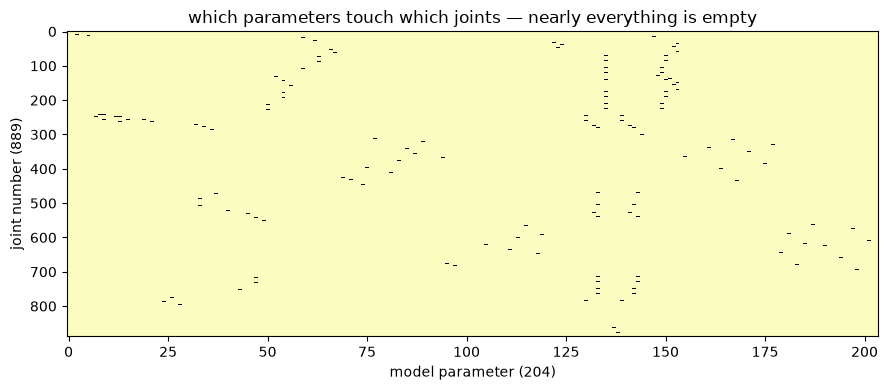

In [17]:
parameter_transform = character.parameter_transform
# The matrix may arrive dense or sparse depending on the build; make it a plain array either way.
raw_transform = parameter_transform.transform
transform_matrix = np.asarray(raw_transform.todense() if hasattr(raw_transform, "todense") else raw_transform)

print("transform matrix:", transform_matrix.shape, "= 889 joint numbers x 321 input parameters")
print("  columns   0..203 : the model parameters (pose and proportions)  <- all we use")
print("  columns 204..248 : identity coefficients (body shape)")
print("  columns 249..320 : facial expression")
print(f"\nnon-zero entries: {np.count_nonzero(transform_matrix)} out of {transform_matrix.size}"
      f"  ({100 * np.count_nonzero(transform_matrix) / transform_matrix.size:.2f}%)")

figure, axes = plt.subplots(figsize=(9, 4))
axes.imshow(np.abs(transform_matrix[:, :204]) > 0, aspect="auto", cmap="magma_r", interpolation="nearest")
axes.set(xlabel="model parameter (204)", ylabel="joint number (889)",
         title="which parameters touch which joints — nearly everything is empty")
plt.tight_layout()
plt.show()

The relationship is not one-to-one in either direction, and both exceptions matter:

In [18]:
def joints_driven_by(parameter_name):
    """Which joints does one named parameter move?"""
    column = transform_matrix[:, PARAMETER_INDEX[parameter_name]]
    rows = np.nonzero(column)[0]
    return sorted({row // 7 for row in rows})        # 7 numbers per joint, so row // 7 is the joint


def parameters_driving(joint_name):
    """Which named parameters can move one joint?"""
    joint = JOINT_INDEX[joint_name]
    block = transform_matrix[7 * joint: 7 * joint + 7, :204]
    return [PARAMETER_NAMES[c] for c in np.nonzero(np.abs(block).sum(0))[0]]


print("Some parameters move exactly one joint:")
for name in ["l_elbow_bend", "l_knee_bend"]:
    driven = joints_driven_by(name)
    print(f"  {name:<18} -> {[JOINT_NAMES[j] for j in driven]}")

print("\nOthers spread across many joints at once:")
for name in ["l_lowarm_twist", "scale_uplegs"]:
    driven = joints_driven_by(name)
    names = [JOINT_NAMES[j] for j in driven]
    print(f"  {name:<18} -> {len(names)} joints: {names[:4]} ...")

print("\nAnd going the other way, one joint can be driven by many parameters:")
for name in ["l_lowarm", "c_spine1"]:
    print(f"  {name:<12} <- {parameters_driving(name)}")

Some parameters move exactly one joint:
  l_elbow_bend       -> ['l_lowarm']
  l_knee_bend        -> ['l_lowleg']

Others spread across many joints at once:
  l_lowarm_twist     -> 5 joints: ['l_wrist_twist', 'l_lowarm_twist1_proc', 'l_lowarm_twist2_proc', 'l_lowarm_twist3_proc'] ...
  scale_uplegs       -> 10 joints: ['l_lowleg', 'l_upleg_twist1_proc', 'l_upleg_twist2_proc', 'l_upleg_twist3_proc'] ...

And going the other way, one joint can be driven by many parameters:
  l_lowarm     <- ['l_elbow_bend', 'arm_length_flexible', 'scale_uparms']
  c_spine1     <- ['spine_twist0', 'spine_lean0', 'spine_bend0', 'spine1_rx_flexible', 'spine_twist1', 'spine1_ry_flexible', 'spine_lean1', 'spine1_rz_flexible', 'spine_bend1', 'spine_length_flexible', 'scale_spine_length']


`l_elbow_bend` is the simple case: one dial, one joint. `l_lowarm_twist` is the fractional-twist
trick from Part 2, now visible in the matrix — one dial spread over five joints so the forearm
twists gradually. `scale_uplegs` is a *proportion* rather than a pose: it lengthens both thighs,
which means touching every joint hanging off them.

Reading the second list the other way round is just as important. `c_spine1` responds to eleven
different parameters, because bending, leaning, twisting and stretching the spine all land on the
same joints and simply add up.

This layer is also where **joint limits** live: the rig ships sensible ranges so that an elbow
cannot bend backwards.

In [19]:
limits = {}
for limit in character.parameter_limits:
    minmax = limit.data.minmax                      # the accessor is nested one level deeper than it looks
    if minmax is not None:
        limits[PARAMETER_NAMES[minmax.model_parameter_index]] = (minmax.min, minmax.max)

print(f"{len(limits)} parameters carry authored limits. A few:\n")
for name in ["l_elbow_bend", "l_knee_bend", "l_uparm_twist", "spine_bend0"]:
    low, high = limits[name]
    print(f"  {name:<16} {low:+.2f} .. {high:+.2f} rad   ({np.degrees(low):+7.1f}° .. {np.degrees(high):+7.1f}°)")

198 parameters carry authored limits. A few:

  l_elbow_bend     -0.50 .. +2.00 rad   (  -28.6° ..  +114.6°)
  l_knee_bend      +0.00 .. +2.80 rad   (   +0.0° ..  +160.4°)
  l_uparm_twist    -1.50 .. +1.80 rad   (  -85.9° ..  +103.1°)
  spine_bend0      -0.50 .. +1.50 rad   (  -28.6° ..   +85.9°)


---
## Part 8 — What does changing one parameter do?

Now the payoff. We have a chain (Part 2), frames (Part 3), transforms (Part 4–5), and forward
kinematics (Part 6). Turning one dial should move exactly the part of the chain below that joint —
and nothing else.

Let's sweep the left elbow from straight to fully bent and watch.

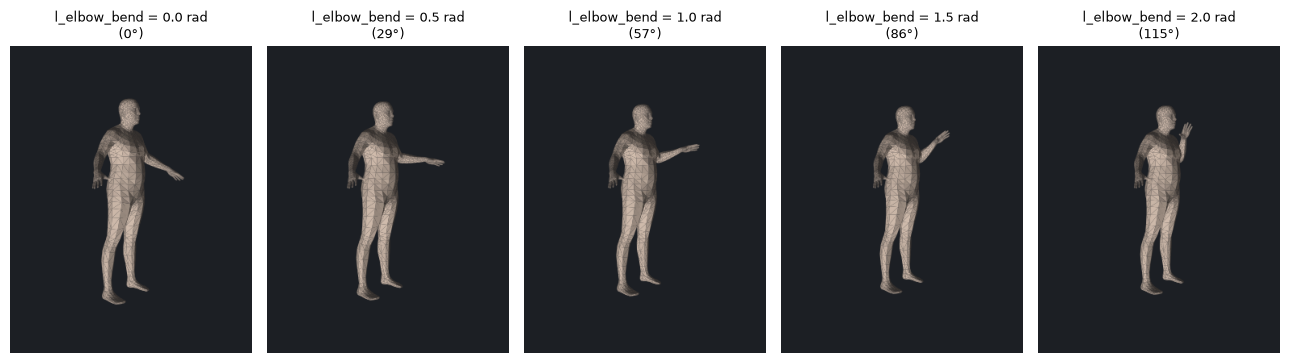

In [20]:
sweep_angles = np.linspace(0.0, 2.0, 5)          # radians, straight -> fully bent

figure = plt.figure(figsize=(13, 3.6))
for panel, angle in enumerate(sweep_angles):
    vertices, joints = pose_body(l_elbow_bend=angle)
    axes_image = figure.add_subplot(1, len(sweep_angles), panel + 1)
    axes_image.imshow(photograph(vertices, azimuth=55, size=(300, 380)))
    axes_image.axis("off")
    axes_image.set_title(f"l_elbow_bend = {angle:.1f} rad\n({np.degrees(angle):.0f}°)", fontsize=9)
plt.tight_layout()
plt.show()

Measured rather than eyeballed: which joints actually moved?

In [21]:
_, straight_joints = pose_body()
_, bent_joints = pose_body(l_elbow_bend=1.5)

travel = np.linalg.norm(bent_joints - straight_joints, axis=1)     # cm moved, per joint
moved = np.nonzero(travel > 0.01)[0]

print(f"bending the left elbow by 1.5 rad moved {len(moved)} of 127 joints:\n")
for joint in moved[:12]:
    print(f"  {JOINT_NAMES[joint]:<22} {travel[joint]:6.2f} cm")
print(f"  ... and {len(moved) - 12} more (the left hand's fingers)")

print("\nDid anything NOT below the elbow move?")
elbow = JOINT_INDEX["l_lowarm"]
# is_ancestor(joint, ancestor) -> True when `ancestor` is above `joint` in the tree.
outside = [j for j in moved if not (j == elbow or skeleton.is_ancestor(int(j), elbow))]
print("  ", [JOINT_NAMES[j] for j in outside] or "nothing — only the elbow's descendants moved")

bending the left elbow by 1.5 rad moved 28 of 127 joints:

  l_wrist_twist           36.81 cm
  l_wrist                 36.81 cm
  l_pinky0                39.67 cm
  l_pinky1                45.76 cm
  l_pinky2                49.85 cm
  l_pinky3                52.53 cm
  l_pinky_null            55.29 cm
  l_ring1                 47.03 cm
  l_ring2                 52.20 cm
  l_ring3                 55.73 cm
  l_ring_null             58.72 cm
  l_middle1               47.87 cm
  ... and 16 more (the left hand's fingers)

Did anything NOT below the elbow move?
   nothing — only the elbow's descendants moved


Exactly the descendants of the elbow, and nothing above it. This is the property that makes rigs
usable: **a joint's influence is its sub-tree.** The shoulder is untouched, the spine is
untouched, the other arm is untouched.

Compare that with rotating something high in the chain, where the sub-tree is most of the body:

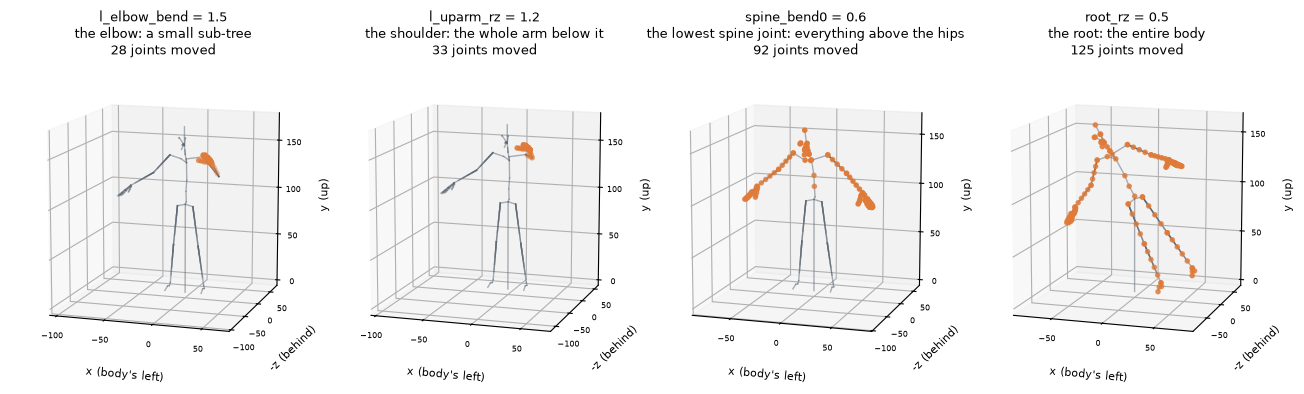

In [22]:
comparisons = [
    ("l_elbow_bend", 1.5, "the elbow: a small sub-tree"),
    ("l_uparm_rz", 1.2, "the shoulder: the whole arm below it"),
    ("spine_bend0", 0.6, "the lowest spine joint: everything above the hips"),
    ("root_rz", 0.5, "the root: the entire body"),
]

figure = plt.figure(figsize=(13, 3.8))
for panel, (name, value, caption) in enumerate(comparisons):
    _, moved_joints = pose_body(**{name: value})
    distance = np.linalg.norm(moved_joints - straight_joints, axis=1)
    count = int((distance > 0.01).sum())

    axes_3d = figure.add_subplot(1, 4, panel + 1, projection="3d")
    draw_skeleton(axes_3d, moved_joints, color="#5a6672",
                  title=f"{name} = {value}\n{caption}\n{count} joints moved")
    # Redraw only the joints that moved, in orange, straight on top.
    axes_3d.scatter(*for_plotting(moved_joints[distance > 0.01]).T, s=9, color="#e07b39", zorder=5)
    equalise(axes_3d, moved_joints)
plt.tight_layout()
plt.show()

---
## Part 9 — How the transformations combine

Finally, the question the notebook has been building to: *how do individual joint transforms
combine into the finished pose?*

The answer is the one line from Part 6:

```python
world[joint] = world[parent] @ local
```

The best way to feel it is to add the transforms of one chain **one at a time** and watch the
hand walk toward its final position. Below, the same arm pose is built up joint by joint: first
only the collarbone rotates, then the shoulder joins in, then the elbow, then the wrist.

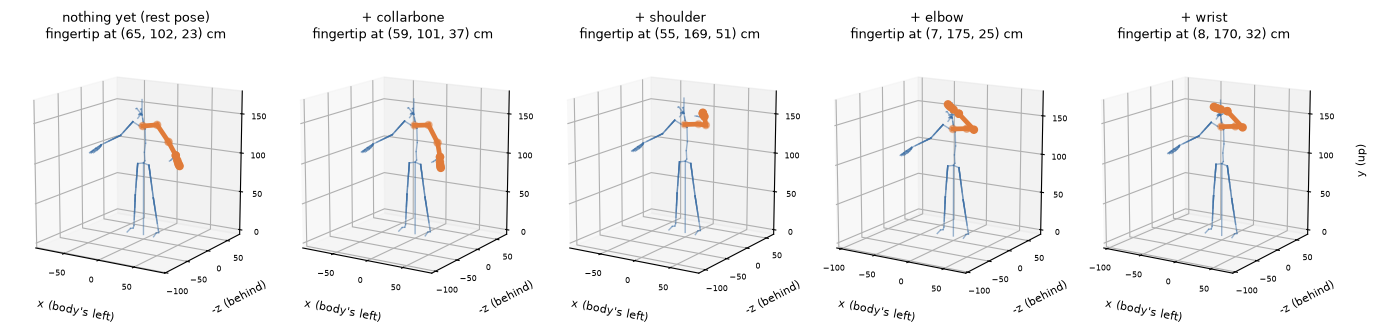

In [23]:
# One arm pose, described joint by joint down the chain, shoulder first.
arm_pose_steps = [
    ("nothing yet (rest pose)", {}),
    ("+ collarbone", {"l_clavicle_rz": 0.25}),
    ("+ shoulder", {"l_clavicle_rz": 0.25, "l_uparm_ry": 0.55, "l_uparm_rz": 0.95}),
    ("+ elbow", {"l_clavicle_rz": 0.25, "l_uparm_ry": 0.55, "l_uparm_rz": 0.95, "l_elbow_bend": 1.35}),
    ("+ wrist", {"l_clavicle_rz": 0.25, "l_uparm_ry": 0.55, "l_uparm_rz": 0.95, "l_elbow_bend": 1.35,
                 "l_wrist_rz": 0.5}),
]

arm_chain = ["l_clavicle", "l_uparm", "l_lowarm", "l_wrist_twist", "l_wrist",
             "l_middle1", "l_middle2", "l_middle3", "l_middle_null"]

# We track the FINGERTIP rather than the wrist joint. A joint's own rotation never moves
# the joint itself -- only its descendants -- so the wrist panel would look unchanged if
# we watched the wrist.
TRACKED = "l_middle_null"

figure = plt.figure(figsize=(13.5, 3.6))
for panel, (caption, parameters) in enumerate(arm_pose_steps):
    _, joints = pose_body(**parameters)
    fingertip = joints[JOINT_INDEX[TRACKED]]

    axes_3d = figure.add_subplot(1, len(arm_pose_steps), panel + 1, projection="3d")
    draw_skeleton(axes_3d, joints, highlight=arm_chain, elevation=14, azimuth=-58,
                  title=f"{caption}\nfingertip at ({fingertip[0]:.0f}, {fingertip[1]:.0f},"
                        f" {fingertip[2]:.0f}) cm")
    equalise(axes_3d, joints)
plt.tight_layout()
plt.show()

Each new rotation is applied **in the frame the previous ones already created**. When the elbow
bends by 1.35 rad it bends about *its own* z axis — which by then is wherever the collarbone and
shoulder have carried it. That is why the same elbow angle would produce a different result if
the shoulder had been placed differently.

Notice the last panel: the wrist rotation moves the fingertip while leaving the wrist joint
itself exactly where it was. A joint's rotation never moves the joint — only everything hanging
below it.

We can watch this in the numbers too, by inspecting the world transforms our own
`forward_kinematics` produced along the chain.

In [24]:
final_parameters = arm_pose_steps[-1][1]

full_vector = np.zeros(321, dtype=np.float32)
full_vector[:204] = make_parameters(**final_parameters)[0].numpy()
joint_parameters = np.asarray(parameter_transform.apply(full_vector)).reshape(-1, 7)
world_transforms = forward_kinematics(joint_parameters)

print("Walking down the arm chain — each row is the PREVIOUS row times one local transform.\n")
print(f"{'joint':<16}{'world position (cm)':<28}{'own x axis points':<24}{'pose angles (rad)'}")
for name in ["root", "c_spine3", "l_clavicle", "l_uparm", "l_lowarm", "l_wrist"]:
    joint = JOINT_INDEX[name]
    position = world_transforms[joint][:3, 3]
    bone_direction = world_transforms[joint][:3, 0]          # column 0 = the joint's x = down the bone
    angles = joint_parameters[joint, 3:6]
    print(f"{name:<16}{str(position.round(1)):<28}{str(bone_direction.round(2)):<24}{angles.round(2)}")

Walking down the arm chain — each row is the PREVIOUS row times one local transform.

joint           world position (cm)         own x axis points       pose angles (rad)
root            [ 0.  92.4  0. ]            [1. 0. 0.]              [0. 0. 0.]
c_spine3        [ -0.  134.8  -3.7]         [ 0.    1.   -0.04]     [0. 0. 0.]
l_clavicle      [  2.8 140.6   6.4]         [ 0.95  0.08 -0.32]     [0.   0.   0.25]
l_uparm         [ 19.5 141.9   0.7]         [0.77 0.15 0.62]        [0.   0.55 0.95]
l_lowarm        [ 39.2 145.8  16.7]         [-0.72  0.68  0.13]     [0.   0.   1.35]
l_wrist         [ 19.7 164.1  20.1]         [-0.72  0.34  0.6 ]     [0.  0.  0.5]


Read the "own x axis" column down the chain: it is the direction each bone points in the world,
and it changes at every step because each local rotation is stacked onto everything above it.

And to close the loop — the skin follows all of it, because every vertex is attached to nearby
joints and rides their world transforms:

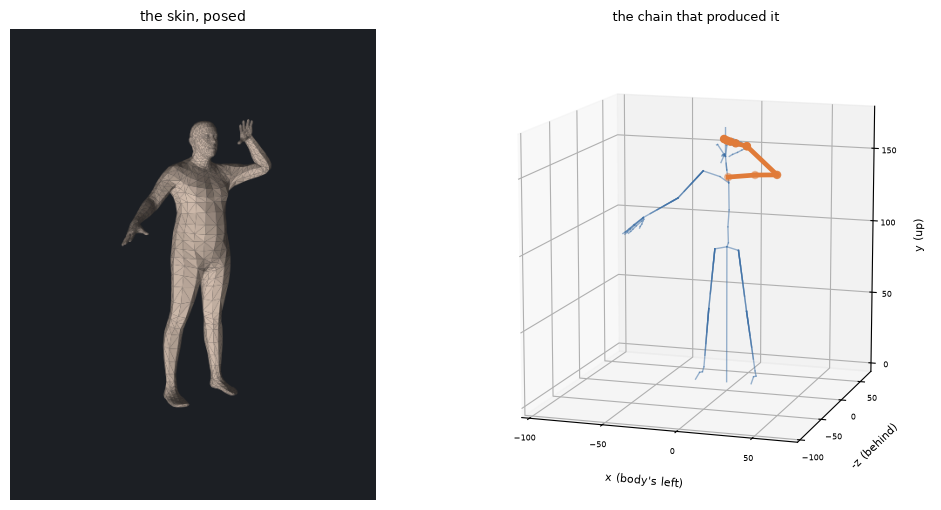

In [25]:
figure = plt.figure(figsize=(10.5, 5.2))

vertices, joints = pose_body(**final_parameters)

axes_image = figure.add_subplot(1, 2, 1)
axes_image.imshow(photograph(vertices, azimuth=35))
axes_image.axis("off")
axes_image.set_title("the skin, posed", fontsize=10)

axes_3d = figure.add_subplot(1, 2, 2, projection="3d")
draw_skeleton(axes_3d, joints, highlight=arm_chain, title="the chain that produced it")
equalise(axes_3d, joints)

plt.tight_layout()
plt.show()

---
## Recap — the answers, in one place

**What geometry is represented?** A triangle mesh (the skin, in centimetres) plus a 127-joint
skeleton. The skeleton is an independent object that drives the skin.

**What is a joint?** A name, a parent index, a rest offset from that parent (which *is* the bone
length), and a fixed pre-rotation. Nothing else.

**What coordinate frames are used?** One fixed world frame (+y up, +z forward, origin on the
floor, cm), and one moving local frame per joint whose x axis runs down its bone.

**What is a transformation?** A rotation plus a translation, packed into a 4×4 matrix so that
chaining them is a single matrix multiply.

**How are rotations and translations represented?** Translations as 3-vectors in cm. Rotations as
three x-y-z Euler angles in radians per joint, applied after that joint's fixed pre-rotation. The
library hands *results* back as quaternions, which are the same rotation in 4 numbers.

**What is forward kinematics in MHR?** Build $L_j = T(\text{offset} + t)\,R^{\text{pre}}\,R_{xyz}(r)\,S(2^s)$
for every joint, then sweep the array once computing $W_j = W_{\text{parent}} \cdot L_j$. We wrote it
in Part 6 and it matched the library to $3\times10^{-5}$ cm.

**How does changing a parameter affect the body?** A named parameter is expanded by the sparse
matrix $T_p$ into raw joint numbers; that joint's rotation changes; and its whole sub-tree —
exactly its sub-tree — moves with it.

**How do the transformations combine?** Each joint's rotation acts in the frame its ancestors
have already established, so the effects multiply down the chain rather than adding.

### Where to go next

* `demos ipynb/demo1.ipynb` — posing, rendering and identity shape.
* `mhr_posing/analytic_ik.py` — the reverse direction: 3D keypoints → pose, in one pass.
* `mhr_posing/mhr_scene.py` — placing a solved body in a camera's frame.